# RetailRocket EDA

Charts only. The numeric summary is produced by `make eda` (`reports/eda.md`).

In [1]:
import matplotlib.pyplot as plt
import polars as pl

from streamline.ingest.events import load_events
from streamline.training.split import time_split

df = load_events().with_columns(pl.from_epoch("ts_ms", time_unit="ms").alias("ts"))
split = time_split(df)
df.head()

ts_ms,user_id,item_id,event,transaction_id,ts
i64,i64,i64,enum,i64,datetime[μs]
1430622004384,693516,297662,"""addtocart""",null,2015-05-03 03:00:04.384
1430622011289,829044,60987,"""view""",null,2015-05-03 03:00:11.289
1430622013048,652699,252860,"""view""",null,2015-05-03 03:00:13.048
1430622024154,1125936,33661,"""view""",null,2015-05-03 03:00:24.154
1430622026228,693516,297662,"""view""",null,2015-05-03 03:00:26.228


## Daily volume by event type, with the time-based split boundaries

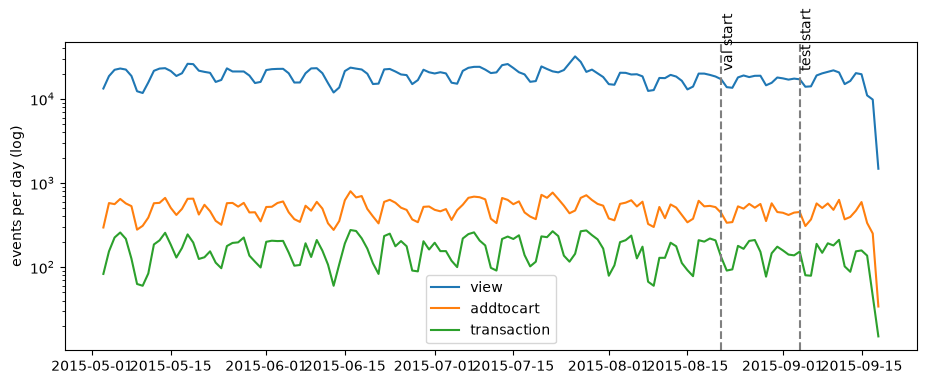

In [2]:
daily = (
    df.group_by(pl.col("ts").dt.date().alias("day"), "event")
    .len()
    .pivot(on="event", index="day", values="len")
    .sort("day")
)
fig, ax = plt.subplots(figsize=(11, 4))
for col in ["view", "addtocart", "transaction"]:
    ax.plot(daily["day"], daily[col], label=col)
ax.set_yscale("log")
for ms, name in [(split.val_start_ms, "val start"), (split.test_start_ms, "test start")]:
    ax.axvline(pl.from_epoch(pl.Series([ms]), time_unit="ms").dt.date()[0], ls="--", c="grey")
    ax.text(pl.from_epoch(pl.Series([ms]), time_unit="ms").dt.date()[0], ax.get_ylim()[1] * 0.5, name, rotation=90)
ax.set_ylabel("events per day (log)")
ax.legend()
plt.show()

## Activity is extremely long-tailed

Most visitors appear once; a few items take a large share of traffic.

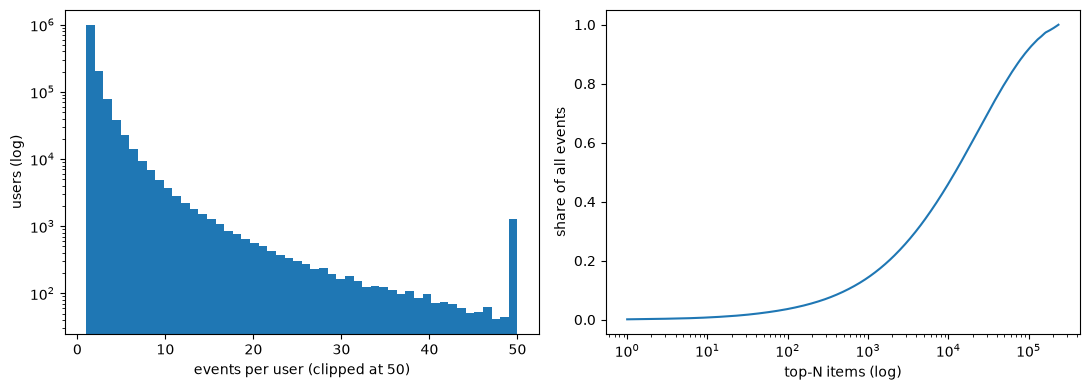

In [3]:
per_user = df.group_by("user_id").len()["len"]
per_item = df.group_by("item_id").len()["len"].sort(descending=True)
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.hist(per_user.clip(upper_bound=50), bins=50)
a.set_yscale("log")
a.set_xlabel("events per user (clipped at 50)")
a.set_ylabel("users (log)")
share = per_item.cum_sum() / per_item.sum()
b.plot(range(1, len(share) + 1), share)
b.set_xscale("log")
b.set_xlabel("top-N items (log)")
b.set_ylabel("share of all events")
plt.tight_layout()
plt.show()

## How much of the target window is repeat behaviour?

Share of test-window user-item pairs (warm users) that the user had already interacted with before the test cutoff. This is why the *recently viewed* baseline is strong and why we also report new-item metrics.

In [4]:
hist, tgt = split.train_val, split.test
warm = tgt.join(hist.select("user_id").unique(), on="user_id", how="semi")
pairs = warm.select("user_id", "item_id").unique()
repeat = pairs.join(hist.select("user_id", "item_id").unique(), on=["user_id", "item_id"], how="semi")
print(f"warm test users: {warm['user_id'].n_unique():,}")
print(f"repeat share of target pairs: {repeat.height / pairs.height:.1%}")

warm test users: 14,774
repeat share of target pairs: 13.9%
